In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import datetime as dt


In [ ]:
df = pd.read_csv('superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Remove null values
df = df.dropna()

# Clean column names
df.columns = df.columns.str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

9994

In [ ]:
query = """
SELECT
    [Customer Name],
    MAX([Order Date]) AS Last_Order_Date,
    COUNT(DISTINCT [Order ID]) AS Frequency,
    SUM(Sales) AS Monetary
FROM sales
GROUP BY [Customer Name]
"""

rfm_sql = pd.read_sql(query, conn)
rfm_sql.head()

,Customer Name,Last_Order_Date,Frequency,Monetary
0,Aaron Bergman,2016-11-10 00:00:00,3,886.156
1,Aaron Hawkins,2017-12-18 00:00:00,7,1744.700
2,Aaron Smayling,2017-10-03 00:00:00,7,3050.692
3,Adam Bellavance,2017-11-06 00:00:00,8,7755.620
4,Adam Hart,2017-11-26 00:00:00,10,3250.337


In [ ]:
rfm_sql['Last_Order_Date'] = pd.to_datetime(rfm_sql['Last_Order_Date'])

reference_date = rfm_sql['Last_Order_Date'].max() + dt.timedelta(days=1)

rfm_sql['Recency'] = (reference_date - rfm_sql['Last_Order_Date']).dt.days

rfm_sql.head()

,Customer Name,Last_Order_Date,Frequency,Monetary,Recency
0,Aaron Bergman,2016-11-10,3,886.156,416
1,Aaron Hawkins,2017-12-18,7,1744.700,13
2,Aaron Smayling,2017-10-03,7,3050.692,89
3,Adam Bellavance,2017-11-06,8,7755.620,55
4,Adam Hart,2017-11-26,10,3250.337,35


In [ ]:
rfm_sql['R_score'] = pd.qcut(rfm_sql['Recency'], 4, labels=[4,3,2,1])
rfm_sql['F_score'] = pd.qcut(rfm_sql['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm_sql['M_score'] = pd.qcut(rfm_sql['Monetary'], 4, labels=[1,2,3,4])

rfm_sql['RFM_Score'] = rfm_sql['R_score'].astype(str) + rfm_sql['F_score'].astype(str) + rfm_sql['M_score'].astype(str)


In [ ]:
def segment(row):
    if row['RFM_Score'] == '444':
        return 'High Value'
    elif int(row['R_score']) >= 3 and int(row['F_score']) >= 3:
        return 'Loyal Customers'
    elif int(row['R_score']) <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm_sql['Segment'] = rfm_sql.apply(segment, axis=1)

rfm_sql.head()

,Customer Name,Last_Order_Date,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_Score,Segment
0,Aaron Bergman,2016-11-10,3,886.156,416,1,1,1,111,At Risk
1,Aaron Hawkins,2017-12-18,7,1744.700,13,4,3,2,432,Loyal Customers
2,Aaron Smayling,2017-10-03,7,3050.692,89,2,3,3,233,At Risk
3,Adam Bellavance,2017-11-06,8,7755.620,55,3,3,4,334,Loyal Customers
4,Adam Hart,2017-11-26,10,3250.337,35,3,4,3,343,Loyal Customers


In [ ]:
rfm_sql['Segment'].value_counts()


,count
Segment,
At Risk,396
Loyal Customers,204
Others,159
High Value,34


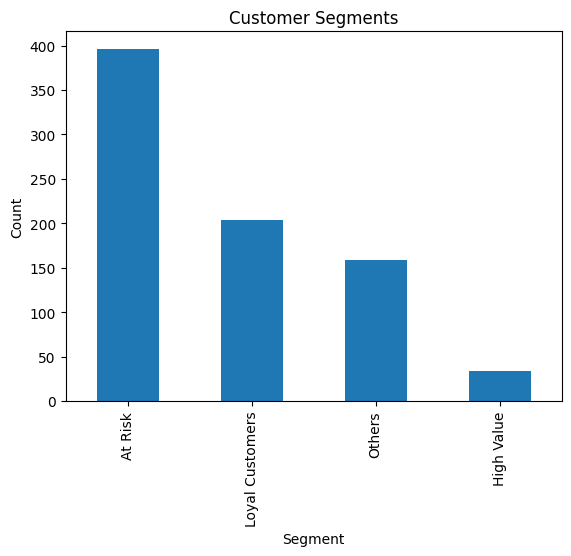

In [ ]:
rfm_sql['Segment'].value_counts().plot(kind='bar')
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

In [ ]:
rfm_sql.to_csv('rfm_output.csv', index=False)